# 03 — Modelagem

Mínimo de **dois** classificadores distintos. Um único modelo não atende ao requisito.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scalers para diferentes comportamentos de dados
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# Modelos Lineares, Estocásticos e SVM
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Árvores e Ensembles (100% nativos do Scikit-Learn)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, accuracy_score
)

RANDOM_STATE = 42

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

PROCESSED = PROJECT_ROOT / "data" / "processed"
TARGET = "target"

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")

Dataset carregado: 36457 registros e 46 colunas.


## 1. Split treino/teste

`stratify` preserva a proporção das classes nos dois conjuntos.

In [3]:
# Removemos ID pois é apenas identificador do cliente e não variável preditiva
X = df.drop(columns=[TARGET, 'ID'])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Taxa de Mau Pagador: {y_train.mean()*100:.2f}%")
print(f"Teste:  {X_test.shape[0]} amostras | Taxa de Mau Pagador: {y_test.mean()*100:.2f}%")

# Salvamos os splits para garantir que o Notebook 04 avalie exatamente o mesmo conjunto de teste
X_train.to_csv(PROCESSED / "X_train.csv", index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False)
X_test.to_csv(PROCESSED / "X_test.csv", index=False)
y_test.to_csv(PROCESSED / "y_test.csv", index=False)

Treino: 29165 amostras | Taxa de Mau Pagador: 1.69%
Teste:  7292 amostras | Taxa de Mau Pagador: 1.69%


## 2. Modelos candidatos

Usar `Pipeline` evita vazamento: o scaler é ajustado só no fold de treino durante a validação cruzada.

In [4]:
modelos = {
    # 1. Regressão Logística com RobustScaler (resistente a outliers nas rendas e valores contínuos)
    "Logistic_Regression (RobustScaler)": Pipeline([
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    
    # 2. SGDClassifier com StandardScaler e perda logística (ElasticNet)
    "SGD_Classifier (StandardScaler)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(loss="log_loss", penalty="elasticnet", class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000)),
    ]),
    
    # 3. Linear SVM Calibrado (com CalibratedClassifierCV para calcular probabilidades e métricas como ROC-AUC)
    "Linear_SVM_Calibrated (StandardScaler)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000, dual="auto"),
            cv=3
        )),
    ]),
    
    # 4. Gaussian Naive Bayes com RobustScaler (densidade contínua)
    "Gaussian_Naive_Bayes (RobustScaler)": Pipeline([
        ("scaler", RobustScaler()),
        ("clf", GaussianNB()),
    ]),
    
    # 5. Bernoulli Naive Bayes com MinMaxScaler (trabalha com variáveis normalizadas no intervalo [0, 1])
    "Bernoulli_Naive_Bayes (MinMaxScaler)": Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", BernoulliNB()),
    ]),
    
    # 6. Decision Tree (Árvore simples como baseline interpretável)
    "Decision_Tree (Sem Scaler)": Pipeline([
        ("clf", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),

    # 7. Random Forest (Bagging com reponderação dinâmica em cada bootstrap)
    "Random_Forest (Sem Scaler)": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=150, max_depth=12, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),

    # 8. Extra Trees (Extremely Randomized Trees - excelente robustez e variância reduzida)
    "Extra_Trees (Sem Scaler)": Pipeline([
        ("clf", ExtraTreesClassifier(n_estimators=150, max_depth=12, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),

    # 9. HistGradientBoosting (Boosting nativo de última geração do Scikit-Learn, inspirado em LightGBM)
    "Hist_Gradient_Boosting (Nativo)": Pipeline([
        ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE, max_iter=150)),
    ]),

    # 10. AdaBoost Classifier (Boosting adaptativo clássico com árvores rasas)
    "AdaBoost (Stump Trees)": Pipeline([
        ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced"), n_estimators=100, random_state=RANDOM_STATE)),
    ]),
}

## 3. Validação cruzada

In [5]:
mcc_scorer = make_scorer(matthews_corrcoef)

scoring = {
    "mcc": mcc_scorer,
    "f1": "f1",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []

print("Iniciando Validação Cruzada (5-Fold Stratified nos 10 Modelos do Scikit-Learn)...")
for nome, modelo in modelos.items():
    cv_res = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados.append({
        "Modelo": nome,
        "MCC": cv_res["test_mcc"].mean(),
        "MCC_Std": cv_res["test_mcc"].std(),
        "F1_Score": cv_res["test_f1"].mean(),
        "ROC_AUC": cv_res["test_roc_auc"].mean(),
        "Recall": cv_res["test_recall"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Accuracy": cv_res["test_accuracy"].mean(),
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="MCC", ascending=False).reset_index(drop=True)
display(df_resultados.style.format({
    "MCC": "{:.4f}", "MCC_Std": "{:.4f}", "F1_Score": "{:.4f}",
    "ROC_AUC": "{:.4f}", "Recall": "{:.4f}", "Precision": "{:.4f}", "Accuracy": "{:.4f}"
}).background_gradient(subset=["MCC", "F1_Score", "ROC_AUC"], cmap="Blues"))

Iniciando Validação Cruzada (5-Fold Stratified nos 10 Modelos do Scikit-Learn)...


/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech

,Modelo,MCC,MCC_Std,F1_Score,ROC_AUC,Recall,Precision,Accuracy
0,Random_Forest (Sem Scaler),0.2480,0.0329,0.2499,0.7358,0.3772,0.1876,0.9618
1,Extra_Trees (Sem Scaler),0.1453,0.0147,0.1207,0.7164,0.4645,0.0694,0.8852
2,Hist_Gradient_Boosting (Nativo),0.1293,0.0242,0.0970,0.7300,0.5535,0.0532,0.8226
3,AdaBoost (Stump Trees),0.1139,0.0218,0.0846,0.7167,0.5557,0.0458,0.7971
4,Decision_Tree (Sem Scaler),0.0468,0.0114,0.0469,0.6378,0.5555,0.0245,0.6194
5,Logistic_Regression (RobustScaler),0.0378,0.0117,0.0443,0.6041,0.5192,0.0231,0.6211
6,SGD_Classifier (StandardScaler),0.0256,0.0073,0.0402,0.5597,0.4888,0.0210,0.6061
7,Gaussian_Naive_Bayes (RobustScaler),0.0113,0.0076,0.0340,0.5657,0.9635,0.0173,0.0730
8,Bernoulli_Naive_Bayes (MinMaxScaler),0.0000,0.0000,0.0000,0.5698,0.0000,0.0000,0.9831
9,Linear_SVM_Calibrated (StandardScaler),0.0000,0.0000,0.0000,0.6027,0.0000,0.0000,0.9831


## 4. Comparação

**Leitura:** _qual modelo venceu e por qual margem? A diferença é relevante ou está dentro do ruído?_

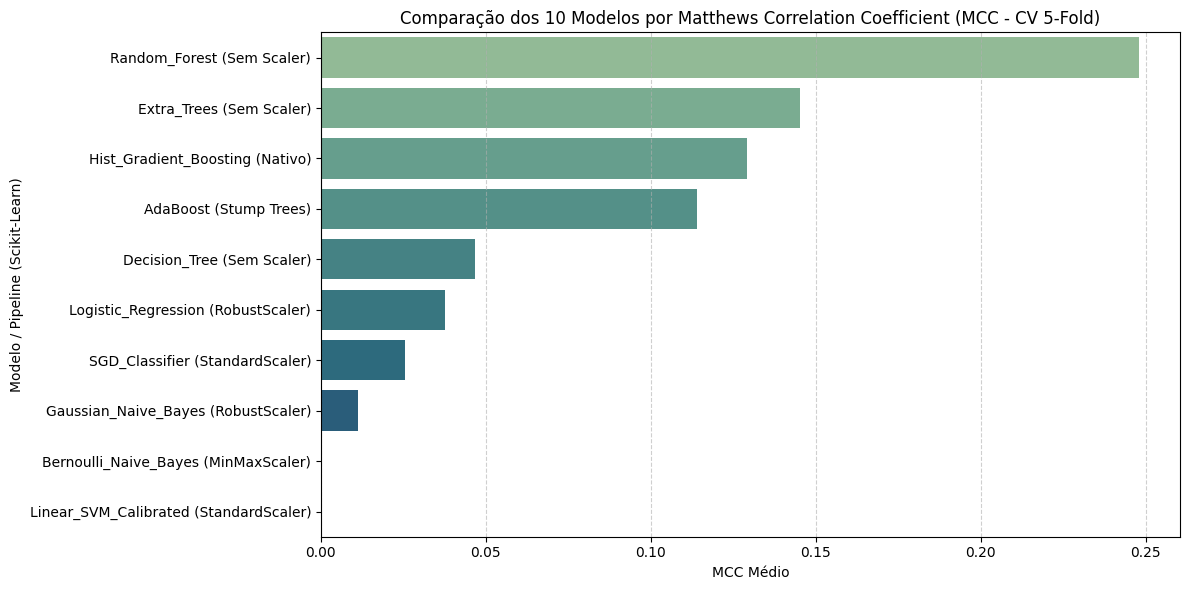

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultados, x="MCC", y="Modelo", palette="crest")
plt.title("Comparação dos 10 Modelos por Matthews Correlation Coefficient (MCC - CV 5-Fold)")
plt.xlabel("MCC Médio")
plt.ylabel("Modelo / Pipeline (Scikit-Learn)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

In [7]:
# Pipeline base para o Tuning
rf_tune_pipeline = Pipeline([
    ("scaler", StandardScaler()), # O tuning pode escolher entre StandardScaler, RobustScaler ou None
    ("clf", RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
])

param_distributions = {
    "scaler": [StandardScaler(), RobustScaler(), "passthrough"],
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [8, 12, 16, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5]
}

random_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring=mcc_scorer,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Executando RandomizedSearchCV (Otimização focada em MCC)...")
random_search.fit(X_train, y_train)

print(f"\nMelhor MCC na Validação Cruzada: {random_search.best_score_:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for k, v in random_search.best_params_.items():
    print(f"  - {k}: {v}")

# Salvamos o melhor estimador treinado para consumo no Notebook 04
melhor_modelo = random_search.best_estimator_
joblib.dump(melhor_modelo, PROCESSED / "melhor_modelo.joblib")
print(f"\nMelhor modelo salvo com sucesso em: {PROCESSED / 'melhor_modelo.joblib'}")

Executando RandomizedSearchCV (Otimização focada em MCC)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Melhor MCC na Validação Cruzada: 0.2964
Melhores Hiperparâmetros encontrados:
  - scaler: StandardScaler()
  - clf__n_estimators: 200
  - clf__min_samples_split: 5
  - clf__min_samples_leaf: 2
  - clf__max_features: 0.5
  - clf__max_depth: 20

Melhor modelo salvo com sucesso em: data/processed/melhor_modelo.joblib


Exception ignored in: <function ResourceTracker.__del__ at 0x7989f266c0e0>
Traceback (most recent call last):
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x764386b7c0e0>
Traceback (most recent call last):
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 